<a href="https://colab.research.google.com/github/tcurtis714/lis4693/blob/main/lab-3/Lab_3_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install and import packages

import pandas as pd
import altair as alt
from vega_datasets import data as vega_data
import requests
import io

In [2]:
# Load data from URL
url = "https://raw.githubusercontent.com/manika-lamba/SP26-LIS4_5693/refs/heads/main/lab-assignments/lab-3/Seattle-Library_2015-2021.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
text = response.text

In [3]:
# Save data as dataframe
seattle_df = pd.read_csv(io.StringIO(text))
seattle_df.head()

,Title,Creator,MaterialType,Checkouts,CheckoutYear,CheckoutMonth,Publisher,PublicationYear,Subjects,UsageClass,CheckoutType
0,Frog and toad all year / by Arnold Lobel.,"Lobel, Arnold",BOOK,34,2016,10,"Harper & Row,",c1976.,"Friendship Fiction, Frogs Juvenile fiction, To...",Physical,Horizon
1,"My brilliant friend : childhood, adolescence /...","Ferrante, Elena",BOOK,110,2016,10,"Europa Editions,",2012,"Friendship Fiction, Naples Italy Fiction",Physical,Horizon
2,Star trek [videorecording] / Paramount ; Spygl...,NaN,VIDEODISC,36,2016,10,"Paramount Home Entertainment,",c2009.,"Kirk James T 2233 2371 Drama, Spock Mr Drama, ...",Physical,Horizon
3,The Man in the High Castle,Philip K. Dick,EBOOK,63,2016,10,Houghton Mifflin Harcourt Trade and Reference,2012,"Fiction, Science Fiction",Digital,OverDrive
4,"The Fifth Season: Broken Earth Series, Book 1",N. K. Jemisin,EBOOK,44,2016,10,"Hachette Digital, Inc.",2015,"Fantasy, Fiction, Thriller",Digital,OverDrive


<Axes: xlabel='MaterialType'>

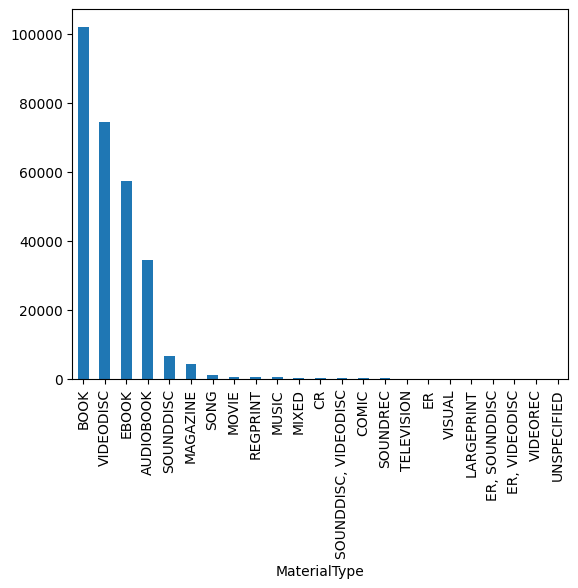

In [4]:
seattle_df['MaterialType'].value_counts().plot(kind='bar')

In [5]:
seattle_df['MaterialType'].value_counts()

,count
MaterialType,
BOOK,102076
VIDEODISC,74473
EBOOK,57299
AUDIOBOOK,34542
SOUNDDISC,6593
MAGAZINE,4197
SONG,975
MOVIE,596
REGPRINT,447


In [6]:
# pandas .value_counts()
type(seattle_df['MaterialType'].value_counts())

pandas.core.series.Series

In [7]:
MaterialType_df = seattle_df['MaterialType'].value_counts().rename_axis('MaterialType').reset_index(name='counts')

In [8]:
source = MaterialType_df
alt.Chart(source).mark_bar().encode(
    x = 'MaterialType',
    y = 'counts'
)

alt.Chart(...)

In [9]:
source = seattle_df['MaterialType'].value_counts().rename_axis('MaterialType').reset_index(name='counts')
alt.Chart(source).mark_bar().encode(
    x=alt.X('MaterialType', sort='-y'),
    y='counts'
)

alt.Chart(...)

In [10]:
cars = vega_data.cars()

alt.Chart(cars).mark_point().encode(
    x='Horsepower',
    y='Miles_per_Gallon',
    color='Origin',
    shape='Origin'
)

alt.Chart(...)

In [11]:
alt.Chart(seattle_df).mark_bar().encode(
     x=alt.X('MaterialType', sort='-y'),
     y='count()',
     color='CheckoutYear:N'
 )

MaxRowsError: The number of rows in your dataset (282287) is greater than the maximum allowed (5000).

Try enabling the VegaFusion data transformer which raises this limit by pre-evaluating data
transformations in Python.
    >> import altair as alt
    >> alt.data_transformers.enable("vegafusion")

Or, see https://altair-viz.github.io/user_guide/large_datasets.html for additional information
on how to plot large datasets.

alt.Chart(...)

In [12]:
seattle_material_grouped = seattle_df.groupby(['MaterialType', 'CheckoutYear']).size().reset_index(name='counts')
alt.Chart(seattle_material_grouped).mark_bar().encode(
    x=alt.X('MaterialType', sort='-y'),
    y='counts',
    color='CheckoutYear:N'
)



alt.Chart(...)

In [13]:
# Chart w/ tooltips interactivity
alt.Chart(seattle_material_grouped).mark_bar().encode(
    x=alt.X('MaterialType', sort='-y'),
    y='counts',
    color='CheckoutYear:N',
    tooltip=['MaterialType', 'counts', 'CheckoutYear']
).interactive()

alt.Chart(...)

In [14]:
# Chart with click actions
selection = alt.selection_point(fields=['CheckoutYear'], bind='legend')
alt.Chart(seattle_material_grouped).mark_bar().encode(
    x=alt.X('MaterialType', sort='-y'),
    y='counts',
    color=alt.Color('CheckoutYear:N', sort=alt.EncodingSortField('CheckoutYear', order='descending')),
    tooltip=['MaterialType', 'counts', 'CheckoutYear'],
    opacity=alt.condition(selection, alt.value(1), alt.value(0.2)),
    order='CheckoutYear'
).add_params(
    selection
)

alt.Chart(...)